<a href="https://colab.research.google.com/github/raaedkhaan/Ai-lab-tasks/blob/main/Implementation%20and%20MIN-MAX%20algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Input Size  BFS Time  DFS Time
0        1000  0.000564  0.000378
1       40000  0.072369  0.021459
2       80000  0.082168  0.026997
3      200000  0.185675  0.065041
4     1000000  0.855335  0.872590


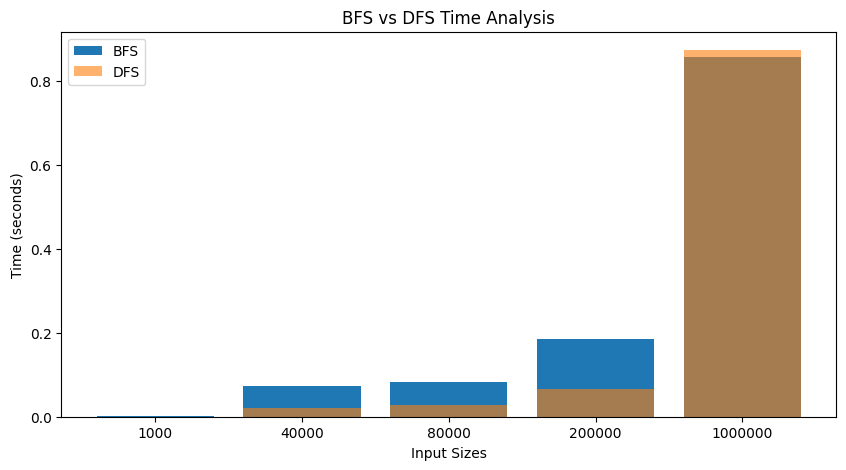

In [ ]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

# Proper BFS for searching in a list treated as tree
def bfs_search_tree(data, goal):
    if not data: return False
    queue = deque([0]) # start with index 0 as root
    visited = set()

    while queue:
        idx = queue.popleft()
        if idx in visited or idx >= len(data):
            continue
        visited.add(idx)

        if data[idx] == goal:
            return True

        # Binary tree: left = 2*i+1, right = 2*i+2
        left, right = 2*idx + 1, 2*idx + 2
        if left < len(data): queue.append(left)
        if right < len(data): queue.append(right)
    return False

# Proper DFS for searching
def dfs_search_tree(data, goal):
    if not data: return False
    stack = [0] # start with index 0 as root
    visited = set()

    while stack:
        idx = stack.pop()
        if idx in visited or idx >= len(data):
            continue
        visited.add(idx)

        if data[idx] == goal:
            return True

        # Binary tree: left = 2*i+1, right = 2*i+2
        left, right = 2*idx + 1, 2*idx + 2
        if right < len(data): stack.append(right) # right first so left is popped first
        if left < len(data): stack.append(left)
    return False

sizes = [1000, 40000, 80000, 200000, 1000000]
bfs_times, dfs_times = [], []

for size in sizes:
    data = random.sample(range(size*10), size)
    goal = data[len(data) - 220] # Task ke mutabiq

    # BFS Time
    start = time.time()
    bfs_search_tree(data, goal)
    bfs_times.append(time.time() - start)

    # DFS Time
    start = time.time()
    dfs_search_tree(data, goal)
    dfs_times.append(time.time() - start)

# DataFrame
df = pd.DataFrame({
    "Input Size": sizes,
    "BFS Time": bfs_times,
    "DFS Time": dfs_times
})
print(df)

# Plot
plt.figure(figsize=(10,5))
plt.bar(range(len(sizes)), bfs_times, label='BFS')
plt.bar(range(len(sizes)), dfs_times, alpha=0.6, label='DFS')
plt.xlabel("Input Sizes")
plt.ylabel("Time (seconds)")
plt.title("BFS vs DFS Time Analysis")
plt.xticks(range(len(sizes)), sizes)
plt.legend()
plt.show()

Size: 1000, Min-Max Result: 3590, Time: 0.000877s
Actual Max: 9997, Actual Min: 3
----------------------------------------
Size: 40000, Min-Max Result: 225963, Time: 0.027456s
Actual Max: 399960, Actual Min: 7
----------------------------------------
Size: 80000, Min-Max Result: 346371, Time: 0.048290s
Actual Max: 799991, Actual Min: 9
----------------------------------------
Size: 200000, Min-Max Result: 997425, Time: 0.132530s
Actual Max: 1999996, Actual Min: 5
----------------------------------------


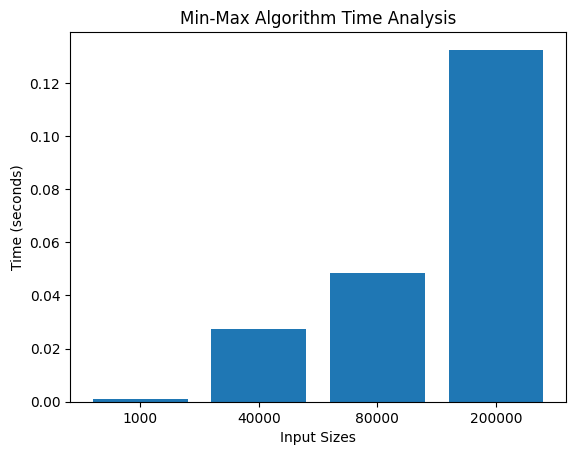

In [ ]:
import random

def min_max(data, depth, is_max):
    """
    Min-Max algorithm:
    is_max = True -> Maximizer ki turn, max value choose karega
    is_max = False -> Minimizer ki turn, min value choose karega
    """
    # Base case: agar list mein 1 element hai
    if len(data) == 1:
        return data[0]

    # List ko 2 halves mein split karo - game tree jaisa
    mid = len(data) // 2
    left_half = data[:mid]
    right_half = data[mid:]

    if is_max:
        return max(min_max(left_half, depth+1, False),
                   min_max(right_half, depth+1, False))
    else:
        return min(min_max(left_half, depth+1, True),
                   min_max(right_half, depth+1, True))

# Test karo
sizes = [1000, 40000, 80000, 200000]
minmax_times = []

for size in sizes:
    data = random.sample(range(size*10), size)

    start = time.time()
    # Assume root is Maximizer
    result = min_max(data, 0, True)
    minmax_times.append(time.time() - start)

    print(f"Size: {size}, Min-Max Result: {result}, Time: {minmax_times[-1]:.6f}s")
    print(f"Actual Max: {max(data)}, Actual Min: {min(data)}")
    print("-" * 40)

# Plot Min-Max Time
plt.bar(range(len(sizes)), minmax_times)
plt.xlabel("Input Sizes")
plt.ylabel("Time (seconds)")
plt.title("Min-Max Algorithm Time Analysis")
plt.xticks(range(len(sizes)), sizes)
plt.show()